In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from itertools import product as iproduct
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

In [19]:
# Конфигурация
DATA_PATH   = "data/data_full.xlsx"   
DATE_COL    = "Дата"             
TARGET_COL  = "NPL_rate"         
HORIZON     = 12                 
N_LAGS      = 12                 
LSTM_EPOCHS = 60
LSTM_BATCH  = 16
OUTPUT_DIR  = "."                

**Загрузка данных**

In [20]:
df = pd.read_excel(DATA_PATH, parse_dates=[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
series = df[TARGET_COL].values
dates  = df[DATE_COL].values

In [21]:
train_end    = len(series) - HORIZON
actual       = series[train_end:]
train_mean   = series[:train_end].mean()
test_dates   = pd.DatetimeIndex(dates[train_end:])

print(f"Train: {len(series[:train_end])} obs  |  Test (horizon): {HORIZON} steps\n")

Train: 175 obs  |  Test (horizon): 12 steps



## Наивная модель

In [59]:
def forecast_naive(series, train_end, horizon):
    """Random-walk: forecast = last observed value."""
    return np.array([series[-train_end-1] for i in range(horizon)])

In [60]:
pred_naive = forecast_naive(series, train_end, HORIZON)

**ARIMA**

In [24]:
def _best_arima_order(train, p_max=3, d_max=1, q_max=3):
    """Grid-search ARIMA(p,d,q) by AIC — no pmdarima needed."""
    best_aic, best_order = np.inf, (1, 1, 0)
    for p, d, q in iproduct(range(p_max+1), range(d_max+1), range(q_max+1)):
        if p == 0 and q == 0:
            continue
        try:
            aic = ARIMA(train, order=(p, d, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, d, q)
        except Exception:
            pass
    return best_order

def forecast_arima(series, train_end, horizon):
    """AIC grid-search ARIMA on initial train; rolling 1-step updates."""
    train = series[:train_end]
    order = _best_arima_order(train)
    print(f"  ARIMA order selected: {order}")
    preds = []
    for i in range(horizon):
        tr = series[:train_end + i]
        try:
            m = ARIMA(tr, order=order).fit()
            preds.append(m.forecast(1)[0])
        except Exception:
            preds.append(tr[-1])          # fallback: naive
    return np.array(preds)

In [ ]:
pred_arima = forecast_arima(series, train_end, HORIZON)

  ARIMA order selected: (0, 0, 3)


## XGBoost

In [26]:
def forecast_xgboost(series, train_end, horizon, n_lags=N_LAGS):
    """XGBoost with lag features; rolling refit each step."""
    preds = []
    for i in range(horizon):
        tr  = series[:train_end + i]
        X   = np.array([tr[j-n_lags:j] for j in range(n_lags, len(tr))])
        y   = tr[n_lags:]
        mdl = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                           subsample=0.8, random_state=42, verbosity=0)
        mdl.fit(X, y)
        preds.append(mdl.predict(tr[-n_lags:].reshape(1, -1))[0])
    return np.array(preds)

In [27]:
pred_xgb = forecast_xgboost(series, train_end, HORIZON)

## LSTM

In [29]:
def forecast_lstm(series, train_end, horizon,
                  n_lags=N_LAGS, epochs=LSTM_EPOCHS, batch=LSTM_BATCH):
    """LSTM with MinMax scaling; rolling refit each step."""
    scaler = MinMaxScaler()
    preds  = []
    tf.random.set_seed(42)

    for i in range(horizon):
        tr_raw = series[:train_end + i].reshape(-1, 1)
        tr_sc  = scaler.fit_transform(tr_raw)

        X = np.array([tr_sc[j-n_lags:j, 0] for j in range(n_lags, len(tr_sc))])
        y = tr_sc[n_lags:, 0]
        X = X.reshape(-1, n_lags, 1)

        mdl = Sequential([
            LSTM(32, input_shape=(n_lags, 1)),
            Dropout(0.2),
            Dense(1),
        ])
        mdl.compile(optimizer="adam", loss="mse")
        mdl.fit(X, y, epochs=epochs, batch_size=batch, verbose=0,
                validation_split=0.1,
                callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])

        x_pred  = tr_sc[-n_lags:].reshape(1, n_lags, 1)
        pred_sc = mdl.predict(x_pred, verbose=0)[0, 0]
        preds.append(scaler.inverse_transform([[pred_sc]])[0, 0])
        print(f"  LSTM step {i+1}/{horizon}", flush=True)

    return np.array(preds)

In [28]:
pred_lstm = forecast_lstm(series, train_end, HORIZON)

  LSTM step 1/12
  LSTM step 2/12
  LSTM step 3/12
  LSTM step 4/12
  LSTM step 5/12
  LSTM step 6/12
  LSTM step 7/12
  LSTM step 8/12
  LSTM step 9/12
  LSTM step 10/12
  LSTM step 11/12
  LSTM step 12/12


## Итоговая оценка моделей

In [61]:
forecasts = {
    "Naive":   pred_naive,
    "ARIMA":   pred_arima,
    "XGBoost": pred_xgb,
    "LSTM":    pred_lstm,
}

**Метрики**

In [ ]:
def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

def mae(y, yhat):
    return mean_absolute_error(y, yhat)

def oos_r2(y, yhat, benchmark_mean):
    """
    Out-of-Sample R² (Campbell & Thompson, 2008).
    Positive → model beats historical-mean benchmark.
    """
    ss_res = np.sum((np.array(y) - np.array(yhat)) ** 2)
    ss_tot = np.sum((np.array(y) - benchmark_mean) ** 2)
    return 1 - ss_res / ss_tot

def diebold_mariano(e_bench, e_model, h=1):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold correction.
    H0: equal predictive accuracy between benchmark and model.
    Negative DM → model is BETTER than benchmark.
    Returns (dm_stat, p_value).
    """
    e1, e2 = np.array(e_bench), np.array(e_model)
    d      = e1 ** 2 - e2 ** 2
    n      = len(d)
    mean_d = np.mean(d)
    gamma  = [np.mean((d - mean_d) * np.roll(d - mean_d, k)) for k in range(h)]
    var_d  = (gamma[0] + 2 * sum(gamma[1:])) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_raw = mean_d / np.sqrt(var_d)
    # HLN correction factor
    hln    = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n) * dm_raw
    p_val  = 2 * (1 - stats.norm.cdf(abs(hln)))
    return round(hln, 4), round(p_val, 4)

In [62]:
errors  = {m: actual - p for m, p in forecasts.items()}
metrics = {}
for m, p in forecasts.items():
    metrics[m] = {
        "RMSE":   round(rmse(actual, p), 6),
        "MAE":    round(mae(actual, p), 6),
        "OOS-R²": round(oos_r2(actual, p, train_mean), 4),
    }

dm_results = {}
for m in ["ARIMA", "XGBoost", "LSTM"]:
    stat, pval = diebold_mariano(errors["Naive"], errors[m])
    dm_results[m] = {"DM-stat": stat, "p-value": pval}

In [63]:
print(pd.DataFrame(metrics).T.to_string())

             RMSE       MAE  OOS-R²
Naive    0.003941  0.003643 -5.8089
ARIMA    0.000838  0.000620  0.6920
XGBoost  0.000975  0.000746  0.5829
LSTM     0.001775  0.001200 -0.3816


In [64]:
for m, v in dm_results.items():
    sig = "✓ significant" if v["p-value"] < 0.05 else "not significant"
    print(f"  {m:8s}: DM={v['DM-stat']:7.4f}  p={v['p-value']:.4f}  {sig}")

  ARIMA   : DM= 4.3804  p=0.0000  ✓ significant
  XGBoost : DM= 4.7299  p=0.0000  ✓ significant
  LSTM    : DM= 5.9349  p=0.0000  ✓ significant


**Визуализация**

Text(0.5, 0.99, 'Time Series Forecasting — NPL Rate\nRolling 12-Step Horizon | Monthly Data')

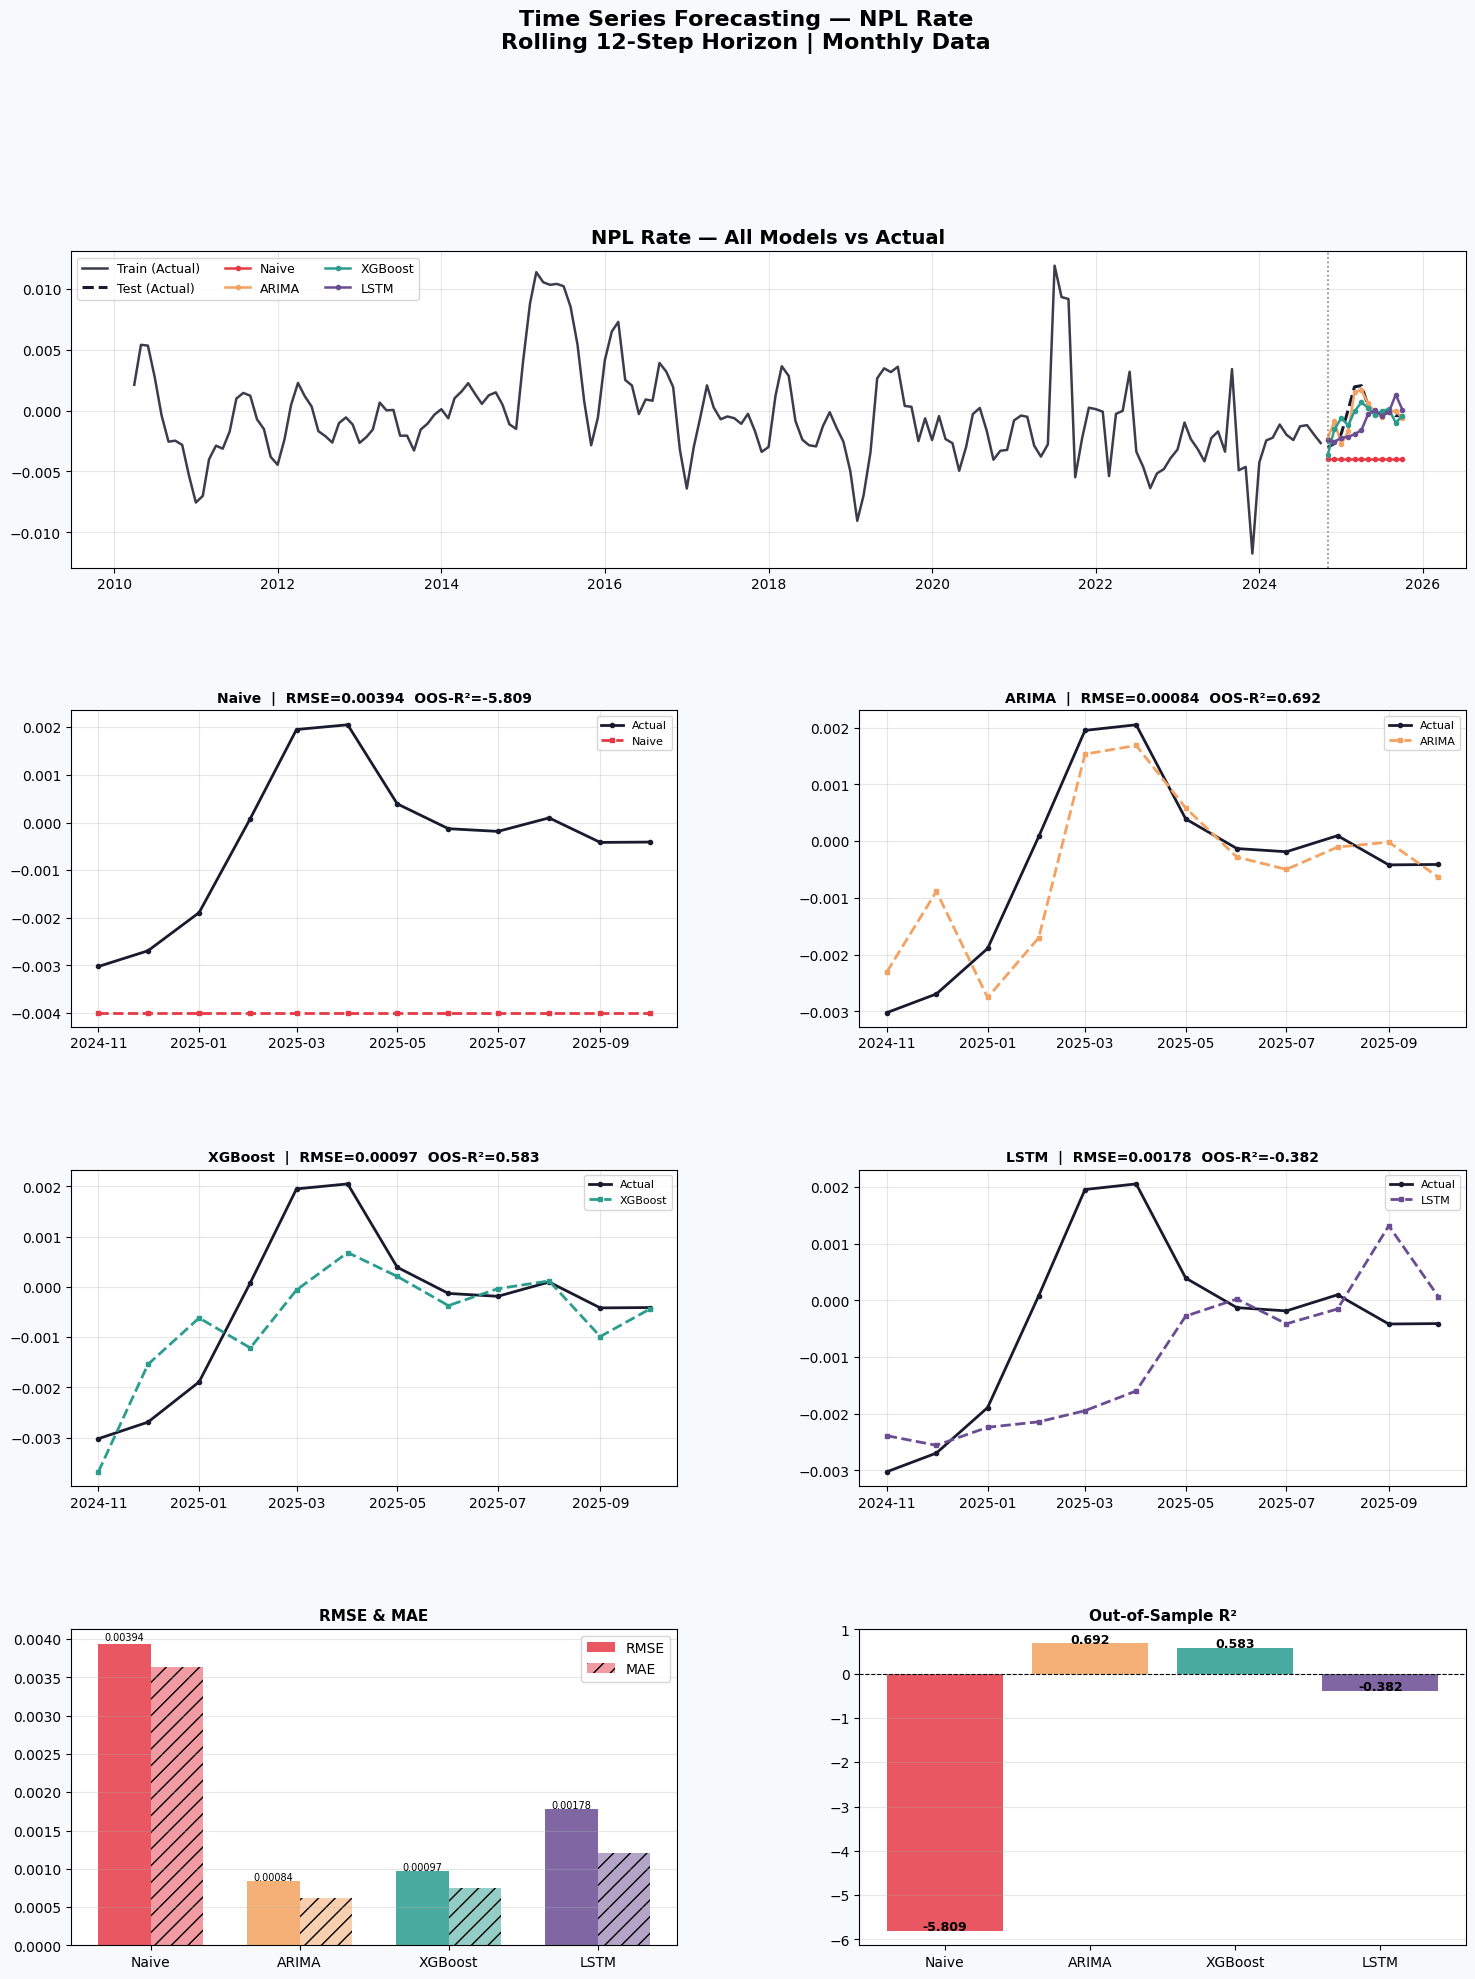

In [ ]:
PALETTE = {
    "Actual":  "#1a1a2e",
    "Naive":   "#e63946",
    "ARIMA":   "#f4a261",
    "XGBoost": "#2a9d8f",
    "LSTM":    "#6a4c93",
}

all_dates  = pd.DatetimeIndex(dates)
train_d    = all_dates[:train_end]
test_d     = all_dates[train_end:]
actual     = series[train_end:]
models     = list(forecasts.keys())

fig = plt.figure(figsize=(18, 22), facecolor="#f8f9fa")
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# Panel 1 — all forecasts
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_d, series[:train_end], color=PALETTE["Actual"],
             lw=1.8, label="Train (Actual)", alpha=0.85)
ax1.plot(test_d, actual, color=PALETTE["Actual"],
             lw=2.2, ls="--", label="Test (Actual)")
for m, p in forecasts.items():
    ax1.plot(test_d, p, color=PALETTE[m], lw=1.8,
                 marker="o", markersize=3, label=m)
ax1.axvline(test_d[0], color="grey", ls=":", lw=1.2)
ax1.set_title("NPL Rate — All Models vs Actual", fontsize=14, fontweight="bold")
ax1.legend(ncol=3, fontsize=9, framealpha=0.8)
ax1.grid(True, alpha=0.3)

# Panels 2-5 — individual
for (m, p), pos in zip(forecasts.items(),
                           [gs[1,0], gs[1,1], gs[2,0], gs[2,1]]):
    ax = fig.add_subplot(pos)
    ax.plot(test_d, actual, color=PALETTE["Actual"],
                lw=2, marker="o", markersize=3, label="Actual")
    ax.plot(test_d, p, color=PALETTE[m], lw=2,
                marker="s", markersize=3, ls="--", label=m)
    ax.set_title(f"{m}  |  RMSE={metrics[m]['RMSE']:.5f}"
                     f"  OOS-R²={metrics[m]['OOS-R²']:.3f}",
                     fontsize=10, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 6 — RMSE / MAE bars
ax6 = fig.add_subplot(gs[3, 0])
x = np.arange(len(models)); w = 0.35
rmse_v = [metrics[m]["RMSE"] for m in models]
mae_v  = [metrics[m]["MAE"]  for m in models]
b1 = ax6.bar(x - w/2, rmse_v, w, label="RMSE",
                 color=[PALETTE[m] for m in models], alpha=0.85)
ax6.bar(x + w/2, mae_v, w, label="MAE",
            color=[PALETTE[m] for m in models], alpha=0.5, hatch="//")
ax6.set_xticks(x); ax6.set_xticklabels(models)
ax6.set_title("RMSE & MAE", fontsize=11, fontweight="bold")
ax6.legend(); ax6.grid(axis="y", alpha=0.3)
for bar in b1:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{bar.get_height():.5f}", ha="center", fontsize=7)

# Panel 7 — OOS-R²
ax7 = fig.add_subplot(gs[3, 1])
r2_v = [metrics[m]["OOS-R²"] for m in models]
bars = ax7.bar(models, r2_v, color=[PALETTE[m] for m in models], alpha=0.85)
ax7.axhline(0, color="black", lw=0.8, ls="--")
ax7.set_title("Out-of-Sample R²", fontsize=11, fontweight="bold")
ax7.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, r2_v):
    ax7.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005, f"{v:.3f}",
                 ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Time Series Forecasting — NPL Rate\n"
                 f"Rolling {HORIZON}-Step Horizon | Monthly Data",
                 fontsize=16, fontweight="bold", y=0.99)


In [39]:
chart_path = f"{OUTPUT_DIR}/forecast_results.png"

In [40]:
plot_results(series, dates, train_end, forecasts, metrics, chart_path)